## 1. Library Imports and Reproducibility Settings

The following cell imports the required packages and fixes random seeds for reproducibility. TensorFlow operations can still show minor non-determinism depending on the Colab runtime and hardware.

In [2]:

# If running in a new Colab runtime, uncomment the installation line below.
# !pip -q install xgboost imbalanced-learn openpyxl

import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from scipy.stats import entropy

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import SMOTE

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

CLASS_NAMES = ["No Anxiety", "Mild Anxiety", "Moderate Anxiety", "Severe Anxiety", "Very Severe Anxiety"]
LABELS = np.array([0, 1, 2, 3, 4])

OUTPUT_DIR = Path("/content/revised_hars_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Study Configuration

The dataset path and duplicate handling policy are defined here. The recommended policy is `identifier` when a reliable student identifier is available, because it prevents the same respondent from appearing in both training and test subsets. If the final methodological decision is to treat each submitted questionnaire as a separate response, set the policy to `exact` and report this explicitly.

In [3]:

# Change this path if your Excel file is stored elsewhere.
DATA_PATH = "/content/drive/MyDrive/anxietyforCIT/Anxiety.xlsx"
SHEET_NAME = 0

# Duplicate handling options: "identifier", "exact", or "none".
# Recommended for the final analysis: "identifier" if the identifier column is reliable.
DUPLICATE_POLICY = "identifier"
IDENTIFIER_COLUMN_CANDIDATES = ["NPM", "NPM ", "Student ID", "Student Identification Number"]

# Main experiment settings.
TEST_SIZE = 0.20
N_SPLITS = 5

# Robustness settings.
MISSING_ITEM_LEVELS = [0, 2, 4, 6]
NOISE_RATES = [0.00, 0.10, 0.20, 0.30]

# To reduce runtime during early debugging, set this to False.
RUN_STACKING_ROBUSTNESS = True

## 3. Data Loading

This section loads the raw questionnaire file. Column names are stripped of leading and trailing spaces to avoid accidental mismatches.

In [4]:

from google.colab import drive

drive.mount('/content/drive')

raw_df = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)
raw_df.columns = [str(c).strip() for c in raw_df.columns]

print("Raw dataset shape:", raw_df.shape)
print("Columns:")
for i, col in enumerate(raw_df.columns, 1):
    print(f"{i:02d}. {col}")

Mounted at /content/drive
Raw dataset shape: (350, 37)
Columns:
01. Cap waktu
02. Nama Lengkap
03. NPM
04. Program Studi
05. Semester
06. Umur
07. Jenis Kelamin
08. Tanggal Pengisian Kusioner
09. Perasaan Ansietas (Cemas)  *Silahkan pilih salah satu
10. Dari pilihan yang kamu pilih diatas, pilih skor 0 - 4 berapa tingkat ansietas kamu?
11. Ketegangan *Silahkan pilih salah satu di bawah ini
12. Dari pilihan yang kamu pilih diatas, pilih skor 0 - 4 berapa tingkat ketegangan kamu?
13. Ketakutan *Silahkan pilih salah satu di bawah ini
14. Dari pilihan yang kamu pilih diatas, pilih skor 0 - 4 berapa tingkat Ketakutan kamu?
15. Gangguan Tidur  *Silahkan pilih salah satu di bawah ini
16. Dari pilihan yang kamu pilih diatas, pilih skor 0 - 4 berapa tingkat gangguan tidur kamu?
17. Gangguan Kecerdasan *Silahkan pilih salah satu di bawah ini
18. Dari pilihan yang kamu pilih diatas, pilih skor 0 - 4 berapa tingkat gangguan kognitif kamu?
19. Gangguan depresi *Silahkan pilih salah satu di bawah in

## 4. Identifier and Metadata Audit

Identifying fields and non-HARS metadata are excluded from model inputs. They may be used temporarily for duplicate screening, but they must not be used as predictive features.

In [5]:

def find_existing_column(df, candidates):
    lower_map = {c.lower(): c for c in df.columns}
    for candidate in candidates:
        if candidate.lower().strip() in lower_map:
            return lower_map[candidate.lower().strip()]
    return None

identifier_col = find_existing_column(raw_df, IDENTIFIER_COLUMN_CANDIDATES)
print("Identifier column detected:", identifier_col)

metadata_keywords = [
    "cap waktu", "nama", "npm", "program", "semester", "umur", "jenis kelamin", "tanggal"
]
metadata_cols = [c for c in raw_df.columns if any(k in c.lower() for k in metadata_keywords)]
print("Potential identifier/metadata columns:")
for col in metadata_cols:
    print("-", col)

Identifier column detected: NPM
Potential identifier/metadata columns:
- Cap waktu
- Nama Lengkap
- NPM
- Program Studi
- Semester
- Umur
- Jenis Kelamin
- Tanggal Pengisian Kusioner


## 5. Duplicate Screening

Duplicate screening is performed before modelling. The selected policy must be reported consistently in the manuscript. The raw identifier is not used after this stage.

In [6]:

df = raw_df.copy()

initial_n = len(df)
exact_duplicate_n = int(df.duplicated().sum())
identifier_duplicate_n = None

if identifier_col is not None:
    identifier_duplicate_n = int(df.duplicated(subset=[identifier_col], keep=False).sum())

print("Initial responses:", initial_n)
print("Exact duplicate rows:", exact_duplicate_n)
print("Rows involved in identifier duplicates:", identifier_duplicate_n)

if DUPLICATE_POLICY == "identifier":
    if identifier_col is None:
        raise ValueError("Identifier-based duplicate screening was requested, but no identifier column was detected.")
    df = df.drop_duplicates(subset=[identifier_col], keep="last").copy()
    print("Duplicate policy applied: identifier-based, keeping the last response per identifier.")
elif DUPLICATE_POLICY == "exact":
    df = df.drop_duplicates().copy()
    print("Duplicate policy applied: exact duplicate rows removed.")
elif DUPLICATE_POLICY == "none":
    print("Duplicate policy applied: no duplicate removal.")
else:
    raise ValueError("DUPLICATE_POLICY must be one of: 'identifier', 'exact', or 'none'.")

print("Retained responses after duplicate screening:", len(df))

Initial responses: 350
Exact duplicate rows: 21
Rows involved in identifier duplicates: 88
Duplicate policy applied: identifier-based, keeping the last response per identifier.
Retained responses after duplicate screening: 306


## 6. HARS Item Extraction and Validation

The 14 HARS item-score columns are detected from the questionnaire score prompts. Only numeric item responses in the range 0–4 are retained for modelling. Textual symptom descriptors are not used.

In [7]:

score_cols_raw = [c for c in df.columns if "pilih skor 0 - 4" in c.lower()]
print("Detected HARS score columns:", len(score_cols_raw))
for i, col in enumerate(score_cols_raw, 1):
    print(f"Q{i}: {col}")

assert len(score_cols_raw) == 14, f"Expected 14 HARS item-score columns, but found {len(score_cols_raw)}."

rename_map = {
    score_cols_raw[0]: "Q1_AnxiousMood",
    score_cols_raw[1]: "Q2_Tension",
    score_cols_raw[2]: "Q3_Fears",
    score_cols_raw[3]: "Q4_Insomnia",
    score_cols_raw[4]: "Q5_Intellectual",
    score_cols_raw[5]: "Q6_DepressedMood",
    score_cols_raw[6]: "Q7_SomaticMuscular",
    score_cols_raw[7]: "Q8_SomaticSensory",
    score_cols_raw[8]: "Q9_Cardiovascular",
    score_cols_raw[9]: "Q10_Respiratory",
    score_cols_raw[10]: "Q11_Gastrointestinal",
    score_cols_raw[11]: "Q12_Genitourinary",
    score_cols_raw[12]: "Q13_Autonomic",
    score_cols_raw[13]: "Q14_Behaviour",
}

df = df.rename(columns=rename_map)
HARS_ITEMS = list(rename_map.values())

items = df[HARS_ITEMS].apply(pd.to_numeric, errors="coerce")
missing_item_values = int(items.isna().sum().sum())
print("Missing item-score values before imputation:", missing_item_values)

# If missing values exist, median imputation is used only for item-score cleaning.
# The missing-item robustness experiment is handled separately using controlled masking.
if missing_item_values > 0:
    items = items.fillna(items.median())

item_min = float(items.min().min())
item_max = float(items.max().max())
print("Minimum item score:", item_min)
print("Maximum item score:", item_max)

if item_min < 0 or item_max > 4:
    raise ValueError("At least one HARS item score falls outside the valid range 0–4.")

items = items.astype(int)
print("Final item-response matrix shape:", items.shape)

Detected HARS score columns: 14
Q1: Dari pilihan yang kamu pilih diatas, pilih skor 0 - 4 berapa tingkat ansietas kamu?
Q2: Dari pilihan yang kamu pilih diatas, pilih skor 0 - 4 berapa tingkat ketegangan kamu?
Q3: Dari pilihan yang kamu pilih diatas, pilih skor 0 - 4 berapa tingkat Ketakutan kamu?
Q4: Dari pilihan yang kamu pilih diatas, pilih skor 0 - 4 berapa tingkat gangguan tidur kamu?
Q5: Dari pilihan yang kamu pilih diatas, pilih skor 0 - 4 berapa tingkat gangguan kognitif kamu?
Q6: Dari pilihan yang kamu pilih diatas, pilih skor 0 - 4 berapa tingkat gangguan depresi kamu?
Q7: Dari pilihan yang kamu pilih diatas, pilih skor 0 - 4 berapa tingkat gejala somatik (Otot) kamu?
Q8: Dari pilihan yang kamu pilih diatas, pilih skor 0 - 4 berapa tingkat Gejala Somatik (Sensorik) kamu?
Q9: Dari pilihan yang kamu pilih diatas, pilih skor 0 - 4 berapa tingkat gejala kardiovaskular kamu?
Q10: Dari pilihan yang kamu pilih diatas, pilih skor 0 - 4 berapa tingkat Gejala Respiratori kamu?
Q11: Dar

## 7. Score-Derived Label Construction

HARS severity labels are derived from the complete original item responses. The aggregate total score is used only to construct the outcome label and is not used as a predictive feature.

In [8]:

def assign_hars_severity(total_score):
    if total_score < 14:
        return 0
    elif total_score <= 20:
        return 1
    elif total_score <= 27:
        return 2
    elif total_score <= 41:
        return 3
    else:
        return 4

hars_total_score = items.sum(axis=1)
y = hars_total_score.apply(assign_hars_severity).astype(int).values

label_distribution = pd.Series(y).value_counts().sort_index().rename(index=dict(enumerate(CLASS_NAMES)))
label_distribution_df = label_distribution.reset_index()
label_distribution_df.columns = ["Severity Level", "Number of Responses"]
label_distribution_df["Percentage"] = 100 * label_distribution_df["Number of Responses"] / len(y)

print("Total score range:", int(hars_total_score.min()), int(hars_total_score.max()))
print(label_distribution_df)

label_distribution_df.to_csv(OUTPUT_DIR / "class_distribution.csv", index=False)

Total score range: 0 56
        Severity Level  Number of Responses  Percentage
0           No Anxiety                   29    9.477124
1         Mild Anxiety                   46   15.032680
2     Moderate Anxiety                   91   29.738562
3       Severe Anxiety                  121   39.542484
4  Very Severe Anxiety                   19    6.209150


## 8. Internal Consistency Analysis

Cronbach's alpha is reported to describe the internal consistency of the 14 HARS item responses in the present sample. It is not used as evidence of clinical validity and does not remove the score-derived nature of the labels.

In [9]:

def cronbach_alpha(dataframe):
    data = dataframe.astype(float)
    k = data.shape[1]
    item_variances = data.var(axis=0, ddof=1)
    total_variance = data.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_variances.sum() / total_variance)

alpha = cronbach_alpha(items)
print(f"Cronbach's alpha for the 14 HARS item responses: {alpha:.3f}")

pd.DataFrame({"Statistic": ["Cronbach's alpha"], "Value": [alpha]}).to_csv(
    OUTPUT_DIR / "reliability_analysis.csv", index=False
)

Cronbach's alpha for the 14 HARS item responses: 0.825


## 9. Feature Representation Design

Four representation families are constructed:

1. **Raw item responses**: Q1–Q14.
2. **Non-aggregate pattern descriptors**: dispersion and response diversity descriptors that do not explicitly include total or mean score.
3. **Score-distribution descriptors**: frequency/proportion descriptors of response categories. These are reported transparently because category counts can reconstruct the total score and must not be described as fully non-leaking.
4. **Ordered item sequence**: Q1–Q14 as a 14-step sequence for the LSTM encoder.

In [10]:

def safe_entropy(row_values):
    valid = np.asarray(row_values, dtype=float)
    valid = valid[~np.isnan(valid)]
    if len(valid) == 0:
        return np.nan
    _, counts = np.unique(valid, return_counts=True)
    return entropy(counts)


def build_feature_sets(item_frame):
    """Construct raw, pattern, distribution, combined tabular, and sequence representations."""
    item_frame = item_frame.copy().astype(float)

    raw = item_frame.copy()

    pattern = pd.DataFrame(index=item_frame.index)
    pattern["std_item"] = item_frame.std(axis=1, skipna=True)
    pattern["var_item"] = item_frame.var(axis=1, skipna=True)
    pattern["min_item"] = item_frame.min(axis=1, skipna=True)
    pattern["max_item"] = item_frame.max(axis=1, skipna=True)
    pattern["range_item"] = pattern["max_item"] - pattern["min_item"]
    pattern["iqr_item"] = item_frame.quantile(0.75, axis=1) - item_frame.quantile(0.25, axis=1)
    pattern["entropy_item"] = item_frame.apply(safe_entropy, axis=1)
    pattern["observed_item_count"] = item_frame.notna().sum(axis=1)
    pattern["missing_item_count"] = item_frame.isna().sum(axis=1)

    distribution = pd.DataFrame(index=item_frame.index)
    observed_count = item_frame.notna().sum(axis=1).replace(0, np.nan)
    for value in range(5):
        distribution[f"count_{value}"] = (item_frame == value).sum(axis=1)
        distribution[f"proportion_{value}"] = distribution[f"count_{value}"] / observed_count
    distribution["proportion_high_3_4"] = ((item_frame >= 3).sum(axis=1)) / observed_count
    distribution["proportion_low_0_1"] = ((item_frame <= 1).sum(axis=1)) / observed_count

    # Median imputation is applied to tabular descriptors only after feature construction.
    # The raw item representation uses a sentinel value for controlled missing-item experiments.
    pattern = pattern.replace([np.inf, -np.inf], np.nan).fillna(0)
    distribution = distribution.replace([np.inf, -np.inf], np.nan).fillna(0)

    combined_tabular = pd.concat([pattern, distribution], axis=1)

    raw_for_models = raw.fillna(-1.0)
    sequence = np.expand_dims(raw_for_models.values.astype(float), axis=-1)

    return {
        "raw_items": raw_for_models,
        "pattern_descriptors": pattern,
        "score_distribution_descriptors": distribution,
        "combined_tabular": combined_tabular,
        "sequence": sequence,
    }

feature_sets = build_feature_sets(items)

feature_description = []
for name, feature_object in feature_sets.items():
    if name == "sequence":
        dimension = str(feature_object.shape[1:])
    else:
        dimension = feature_object.shape[1]
    feature_description.append({"Representation": name, "Dimension": dimension})

feature_description_df = pd.DataFrame(feature_description)
print(feature_description_df)
feature_description_df.to_csv(OUTPUT_DIR / "feature_representation_summary.csv", index=False)

                   Representation Dimension
0                       raw_items        14
1             pattern_descriptors         9
2  score_distribution_descriptors        12
3                combined_tabular        21
4                        sequence   (14, 1)


## 10. Train-Test Split

A single stratified split is used across all complete-input experiments. The test set remains untouched until final evaluation.

In [11]:

all_indices = np.arange(len(y))
train_idx, test_idx = train_test_split(
    all_indices,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

y_train = y[train_idx]
y_test = y[test_idx]

print("Development set size:", len(train_idx))
print("Test set size:", len(test_idx))
print("Test distribution:")
print(pd.Series(y_test).value_counts().sort_index().rename(index=dict(enumerate(CLASS_NAMES))))

Development set size: 244
Test set size: 62
Test distribution:
No Anxiety              6
Mild Anxiety            9
Moderate Anxiety       18
Severe Anxiety         25
Very Severe Anxiety     4
Name: count, dtype: int64


## 11. Evaluation Utilities

The utilities below ensure that all metrics are computed consistently across models.

In [12]:

def multiclass_brier_score(y_true, proba, labels=LABELS):
    y_onehot = label_binarize(y_true, classes=labels)
    return float(np.mean(np.sum((proba - y_onehot) ** 2, axis=1)))


def evaluate_predictions(model_name, y_true, y_pred, proba=None):
    result = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Macro-F1": f1_score(y_true, y_pred, average="macro"),
    }
    if proba is not None:
        result["Brier Score"] = multiclass_brier_score(y_true, proba)
    else:
        result["Brier Score"] = np.nan
    return result


def print_model_report(model_name, y_true, y_pred):
    print(f"=== {model_name} ===")
    print("Accuracy          :", accuracy_score(y_true, y_pred))
    print("Balanced Accuracy :", balanced_accuracy_score(y_true, y_pred))
    print("Macro-F1          :", f1_score(y_true, y_pred, average="macro"))
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


def per_class_recall_table(prediction_dict, y_true):
    rows = []
    for model_name, y_pred in prediction_dict.items():
        recalls = recall_score(y_true, y_pred, average=None, labels=LABELS)
        for label, class_name, recall_value in zip(LABELS, CLASS_NAMES, recalls):
            rows.append({"Model": model_name, "Severity Level": class_name, "Recall": recall_value})
    return pd.DataFrame(rows)


def safe_smote(y_values):
    counts = pd.Series(y_values).value_counts()
    min_count = int(counts.min())
    if min_count <= 1:
        return None
    k_neighbors = max(1, min(5, min_count - 1))
    return SMOTE(random_state=RANDOM_STATE, k_neighbors=k_neighbors)

## 12. Model Definitions

Random Forest, SVM, XGBoost, HistGradientBoosting, LSTM, and stacked ensemble models are used. Random seeds are reported for reproducibility, not as structural hyperparameters.

In [13]:

def make_rf():
    return RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
    )


def make_svm():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", SVC(
            C=2.0,
            kernel="rbf",
            gamma="scale",
            probability=True,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )),
    ])


def make_xgboost():
    if not XGBOOST_AVAILABLE:
        return None
    return XGBClassifier(
        n_estimators=800,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
    )


def make_histgb():
    return HistGradientBoostingClassifier(
        max_depth=6,
        learning_rate=0.05,
        max_iter=500,
        random_state=RANDOM_STATE,
    )


def build_lstm_model(input_shape=(14, 1), n_classes=5):
    # -1 is used as the masking value because 0 is a valid HARS response.
    inp = layers.Input(shape=input_shape)
    x = layers.Masking(mask_value=-1.0)(inp)
    x = layers.LSTM(32, return_sequences=False)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation="relu")(x)
    out = layers.Dense(n_classes, activation="softmax")(x)
    model = models.Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

## 13. Main Complete-Input Model Comparison

This section evaluates complete item-response classification. The results should be interpreted as approximation of score-derived HARS severity categories, not as independent clinical diagnosis.

In [14]:

def fit_tabular_model(model, X_train, y_train, X_test, use_smote=False):
    if use_smote:
        smote = safe_smote(y_train)
        if smote is not None:
            X_fit, y_fit = smote.fit_resample(X_train, y_train)
        else:
            X_fit, y_fit = X_train, y_train
    else:
        X_fit, y_fit = X_train, y_train
    model.fit(X_fit, y_fit)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
    return pred, proba, model

X_main = feature_sets["combined_tabular"]
S_main = feature_sets["sequence"]

X_train_main = X_main.iloc[train_idx]
X_test_main = X_main.iloc[test_idx]
S_train_main = S_main[train_idx]
S_test_main = S_main[test_idx]

main_results = []
main_predictions = {}
main_probas = {}

# Tabular models.
for model_name, model in [
    ("Random Forest", make_rf()),
    ("SVM (RBF)", make_svm()),
    ("HistGradientBoosting", make_histgb()),
]:
    pred, proba, fitted_model = fit_tabular_model(model, X_train_main, y_train, X_test_main, use_smote=False)
    main_results.append(evaluate_predictions(model_name, y_test, pred, proba))
    main_predictions[model_name] = pred
    main_probas[model_name] = proba
    print_model_report(model_name, y_test, pred)

if XGBOOST_AVAILABLE:
    pred, proba, fitted_model = fit_tabular_model(make_xgboost(), X_train_main, y_train, X_test_main, use_smote=False)
    main_results.append(evaluate_predictions("XGBoost", y_test, pred, proba))
    main_predictions["XGBoost"] = pred
    main_probas["XGBoost"] = proba
    print_model_report("XGBoost", y_test, pred)

# LSTM sequence model.
n_classes = len(LABELS)
lstm_model = build_lstm_model(input_shape=S_train_main.shape[1:], n_classes=n_classes)
class_weights_array = compute_class_weight(class_weight="balanced", classes=LABELS, y=y_train)
class_weight = {int(label): float(weight) for label, weight in zip(LABELS, class_weights_array)}

lstm_callbacks = [
    callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", patience=5, factor=0.5),
]

lstm_model.fit(
    S_train_main,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=lstm_callbacks,
    class_weight=class_weight,
    verbose=0,
)

lstm_proba = lstm_model.predict(S_test_main, verbose=0)
lstm_pred = np.argmax(lstm_proba, axis=1)
main_results.append(evaluate_predictions("LSTM", y_test, lstm_pred, lstm_proba))
main_predictions["LSTM"] = lstm_pred
main_probas["LSTM"] = lstm_proba
print_model_report("LSTM", y_test, lstm_pred)

=== Random Forest ===
Accuracy          : 0.8387096774193549
Balanced Accuracy : 0.868
Macro-F1          : 0.8681695331695332
                     precision    recall  f1-score   support

         No Anxiety       1.00      0.83      0.91         6
       Mild Anxiety       0.73      0.89      0.80         9
   Moderate Anxiety       0.74      0.78      0.76        18
     Severe Anxiety       0.91      0.84      0.88        25
Very Severe Anxiety       1.00      1.00      1.00         4

           accuracy                           0.84        62
          macro avg       0.88      0.87      0.87        62
       weighted avg       0.85      0.84      0.84        62

=== SVM (RBF) ===
Accuracy          : 0.9032258064516129
Balanced Accuracy : 0.9253333333333333
Macro-F1          : 0.9109687010615802
                     precision    recall  f1-score   support

         No Anxiety       0.86      1.00      0.92         6
       Mild Anxiety       0.80      0.89      0.84         9
   

## 14. Leakage-Safe Stacked Ensemble with Out-of-Fold Meta-Features

The meta-learner is trained only on out-of-fold class probabilities generated within the development set. SMOTE is applied only inside the training portion of each fold.

In [15]:

def fit_stacked_ensemble(X_tabular, sequence_array, y, train_idx, test_idx, use_calibrated_tabular=True):
    X_train = X_tabular.iloc[train_idx]
    X_test = X_tabular.iloc[test_idx]
    S_train = sequence_array[train_idx]
    S_test = sequence_array[test_idx]
    y_train_local = y[train_idx]
    y_test_local = y[test_idx]

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    n_classes = len(LABELS)

    oof_rf = np.zeros((len(y_train_local), n_classes))
    oof_svm = np.zeros((len(y_train_local), n_classes))
    oof_lstm = np.zeros((len(y_train_local), n_classes))

    rf_folds, svm_folds, lstm_folds = [], [], []

    for fold, (tr, va) in enumerate(skf.split(X_train, y_train_local), 1):
        X_tr, X_va = X_train.iloc[tr], X_train.iloc[va]
        y_tr, y_va = y_train_local[tr], y_train_local[va]

        smote = safe_smote(y_tr)
        if smote is not None:
            X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_tr)
        else:
            X_tr_sm, y_tr_sm = X_tr, y_tr

        if use_calibrated_tabular:
            rf_fold = CalibratedClassifierCV(make_rf(), method="sigmoid", cv=3)
            svm_fold = CalibratedClassifierCV(make_svm(), method="sigmoid", cv=3)
        else:
            rf_fold = make_rf()
            svm_fold = make_svm()

        rf_fold.fit(X_tr_sm, y_tr_sm)
        svm_fold.fit(X_tr_sm, y_tr_sm)

        oof_rf[va] = rf_fold.predict_proba(X_va)
        oof_svm[va] = svm_fold.predict_proba(X_va)

        rf_folds.append(rf_fold)
        svm_folds.append(svm_fold)

        S_tr, S_va = S_train[tr], S_train[va]
        class_weights_array = compute_class_weight(class_weight="balanced", classes=LABELS, y=y_tr)
        class_weight = {int(label): float(weight) for label, weight in zip(LABELS, class_weights_array)}

        lstm_fold = build_lstm_model(input_shape=S_tr.shape[1:], n_classes=n_classes)
        lstm_fold.fit(
            S_tr,
            y_tr,
            validation_data=(S_va, y_va),
            epochs=80,
            batch_size=16,
            callbacks=[callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)],
            class_weight=class_weight,
            verbose=0,
        )
        oof_lstm[va] = lstm_fold.predict(S_va, verbose=0)
        lstm_folds.append(lstm_fold)
        print(f"Stacking fold {fold} completed.")

    X_meta_train = np.hstack([oof_rf, oof_svm, oof_lstm])

    # Meta-learner C is selected using OOF meta-features only, not the test set.
    best_meta = None
    for c_value in [0.1, 0.3, 1.0, 3.0, 10.0]:
        candidate = LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            C=c_value,
            random_state=RANDOM_STATE,
        )
        candidate.fit(X_meta_train, y_train_local)
        oof_pred = candidate.predict(X_meta_train)
        oof_balanced = balanced_accuracy_score(y_train_local, oof_pred)
        if best_meta is None or oof_balanced > best_meta["balanced_accuracy"]:
            best_meta = {"model": candidate, "C": c_value, "balanced_accuracy": oof_balanced}

    meta_model = best_meta["model"]
    print("Selected meta-learner C:", best_meta["C"])

    rf_test_proba = np.mean([model.predict_proba(X_test) for model in rf_folds], axis=0)
    svm_test_proba = np.mean([model.predict_proba(X_test) for model in svm_folds], axis=0)
    lstm_test_proba = np.mean([model.predict(S_test, verbose=0) for model in lstm_folds], axis=0)

    X_meta_test = np.hstack([rf_test_proba, svm_test_proba, lstm_test_proba])
    stack_proba = meta_model.predict_proba(X_meta_test)
    stack_pred = meta_model.predict(X_meta_test)

    return {
        "prediction": stack_pred,
        "probability": stack_proba,
        "meta_model": meta_model,
        "base_probabilities": {
            "rf": rf_test_proba,
            "svm": svm_test_proba,
            "lstm": lstm_test_proba,
        },
    }

stacking_output = fit_stacked_ensemble(X_main, S_main, y, train_idx, test_idx, use_calibrated_tabular=True)
stack_pred = stacking_output["prediction"]
stack_proba = stacking_output["probability"]

main_results.append(evaluate_predictions("Stacking (Proposed)", y_test, stack_pred, stack_proba))
main_predictions["Stacking (Proposed)"] = stack_pred
main_probas["Stacking (Proposed)"] = stack_proba
print_model_report("Stacking (Proposed)", y_test, stack_pred)

main_results_df = pd.DataFrame(main_results)
main_results_df = main_results_df.sort_values("Balanced Accuracy", ascending=False)
print(main_results_df)
main_results_df.to_csv(OUTPUT_DIR / "main_performance_table.csv", index=False)

Stacking fold 1 completed.


Stacking fold 2 completed.
Stacking fold 3 completed.
Stacking fold 4 completed.
Stacking fold 5 completed.
Selected meta-learner C: 1.0
=== Stacking (Proposed) ===
Accuracy          : 0.967741935483871
Balanced Accuracy : 0.9777777777777779
Macro-F1          : 0.968235294117647
                     precision    recall  f1-score   support

         No Anxiety       1.00      1.00      1.00         6
       Mild Anxiety       0.82      1.00      0.90         9
   Moderate Anxiety       1.00      0.89      0.94        18
     Severe Anxiety       1.00      1.00      1.00        25
Very Severe Anxiety       1.00      1.00      1.00         4

           accuracy                           0.97        62
          macro avg       0.96      0.98      0.97        62
       weighted avg       0.97      0.97      0.97        62

                  Model  Accuracy  Balanced Accuracy  Macro-F1  Brier Score
5   Stacking (Proposed)  0.967742           0.977778  0.968235     0.050010
4               

## 15. Deterministic HARS Scoring Reference

This is not a competitive predictive baseline. It is the deterministic label-generating rule and is included only to clarify the score-derived nature of the labels.

In [16]:

reference_pred = np.array([assign_hars_severity(score) for score in hars_total_score.iloc[test_idx]])
reference_result = evaluate_predictions("Deterministic HARS Scoring Reference", y_test, reference_pred, None)
print(reference_result)
print("This reference must not be interpreted as a competing machine-learning model.")

{'Model': 'Deterministic HARS Scoring Reference', 'Accuracy': 1.0, 'Balanced Accuracy': np.float64(1.0), 'Macro-F1': 1.0, 'Brier Score': nan}
This reference must not be interpreted as a competing machine-learning model.


## 16. Feature Ablation Study

The ablation study separates raw item responses, non-aggregate pattern descriptors, score-distribution descriptors, sequence encoding, and their fusion. This directly addresses whether the reported performance comes from a particular representation family.

In [17]:

def evaluate_tabular_representation(representation_name, X_representation):
    X_train = X_representation.iloc[train_idx]
    X_test = X_representation.iloc[test_idx]
    model = make_xgboost() if XGBOOST_AVAILABLE else make_rf()
    pred, proba, _ = fit_tabular_model(model, X_train, y_train, X_test, use_smote=False)
    return evaluate_predictions(representation_name, y_test, pred, proba)

ablation_results = []
ablation_results.append(evaluate_tabular_representation("Raw items only", feature_sets["raw_items"]))
ablation_results.append(evaluate_tabular_representation("Non-aggregate pattern descriptors only", feature_sets["pattern_descriptors"]))
ablation_results.append(evaluate_tabular_representation("Score-distribution descriptors only", feature_sets["score_distribution_descriptors"]))
ablation_results.append(evaluate_tabular_representation("Pattern + score-distribution descriptors", feature_sets["combined_tabular"]))
ablation_results.append(evaluate_predictions("Ordered sequence only (LSTM)", y_test, lstm_pred, lstm_proba))
ablation_results.append(evaluate_predictions("Stacking fusion", y_test, stack_pred, stack_proba))

ablation_df = pd.DataFrame(ablation_results).sort_values("Balanced Accuracy", ascending=False)
print(ablation_df)
ablation_df.to_csv(OUTPUT_DIR / "feature_ablation_table.csv", index=False)

                                      Model  Accuracy  Balanced Accuracy  \
5                           Stacking fusion  0.967742           0.977778   
4              Ordered sequence only (LSTM)  0.951613           0.961778   
2       Score-distribution descriptors only  0.870968           0.880889   
3  Pattern + score-distribution descriptors  0.854839           0.876000   
0                            Raw items only  0.806452           0.753778   
1    Non-aggregate pattern descriptors only  0.612903           0.666222   

   Macro-F1  Brier Score  
5  0.968235     0.050010  
4  0.947153     0.078096  
2  0.880010     0.211409  
3  0.876966     0.216076  
0  0.763333     0.277150  
1  0.645571     0.643143  


## 17. Missing-Item Robustness Analysis

This experiment evaluates constrained input settings. Labels remain derived from complete original HARS responses, while a controlled number of item responses is masked before feature construction. This directly addresses the reviewer’s concern about whether the models have a role beyond complete deterministic scoring.

In [18]:

def mask_items_randomly(item_frame, n_missing, seed):
    rng = np.random.default_rng(seed)
    masked = item_frame.astype(float).copy()
    if n_missing == 0:
        return masked
    n_items = masked.shape[1]
    for row_position in range(masked.shape[0]):
        cols_to_mask = rng.choice(n_items, size=min(n_missing, n_items), replace=False)
        masked.iloc[row_position, cols_to_mask] = np.nan
    return masked


def run_lightweight_stacking_or_xgb(item_frame, experiment_name):
    current_features = build_feature_sets(item_frame)
    current_X = current_features["combined_tabular"]
    current_S = current_features["sequence"]

    if RUN_STACKING_ROBUSTNESS:
        output = fit_stacked_ensemble(current_X, current_S, y, train_idx, test_idx, use_calibrated_tabular=True)
        pred = output["prediction"]
        proba = output["probability"]
        return evaluate_predictions(experiment_name, y_test, pred, proba)
    else:
        model = make_xgboost() if XGBOOST_AVAILABLE else make_rf()
        X_train = current_X.iloc[train_idx]
        X_test = current_X.iloc[test_idx]
        pred, proba, _ = fit_tabular_model(model, X_train, y_train, X_test, use_smote=False)
        return evaluate_predictions(experiment_name, y_test, pred, proba)

missing_results = []
for n_missing in MISSING_ITEM_LEVELS:
    masked_items = mask_items_randomly(items, n_missing=n_missing, seed=RANDOM_STATE + n_missing)
    result = run_lightweight_stacking_or_xgb(masked_items, f"Missing items: {n_missing}")
    result["Missing Items per Response"] = n_missing
    missing_results.append(result)

missing_results_df = pd.DataFrame(missing_results)
print(missing_results_df)
missing_results_df.to_csv(OUTPUT_DIR / "missing_item_robustness_table.csv", index=False)

Stacking fold 1 completed.
Stacking fold 2 completed.
Stacking fold 3 completed.
Stacking fold 4 completed.
Stacking fold 5 completed.
Selected meta-learner C: 3.0
Stacking fold 1 completed.
Stacking fold 2 completed.
Stacking fold 3 completed.
Stacking fold 4 completed.
Stacking fold 5 completed.
Selected meta-learner C: 1.0
Stacking fold 1 completed.
Stacking fold 2 completed.
Stacking fold 3 completed.
Stacking fold 4 completed.
Stacking fold 5 completed.
Selected meta-learner C: 3.0
Stacking fold 1 completed.
Stacking fold 2 completed.
Stacking fold 3 completed.
Stacking fold 4 completed.
Stacking fold 5 completed.
Selected meta-learner C: 0.1
              Model  Accuracy  Balanced Accuracy  Macro-F1  Brier Score  \
0  Missing items: 0  0.967742           0.980889  0.974281     0.044520   
1  Missing items: 2  0.887097           0.884000  0.865640     0.197761   
2  Missing items: 4  0.774194           0.823556  0.778135     0.332303   
3  Missing items: 6  0.758065           0.79

## 18. Noisy-Response Robustness Analysis

This experiment perturbs a controlled proportion of item responses by ±1 while keeping values within the valid range 0–4. Labels remain derived from the original complete responses.

In [19]:

def perturb_items_randomly(item_frame, noise_rate, seed):
    rng = np.random.default_rng(seed)
    perturbed = item_frame.astype(int).copy()
    if noise_rate == 0:
        return perturbed
    mask = rng.random(perturbed.shape) < noise_rate
    shifts = rng.choice([-1, 1], size=perturbed.shape)
    values = perturbed.values.copy()
    values[mask] = np.clip(values[mask] + shifts[mask], 0, 4)
    return pd.DataFrame(values, columns=perturbed.columns, index=perturbed.index)

noise_results = []
for noise_rate in NOISE_RATES:
    perturbed_items = perturb_items_randomly(items, noise_rate=noise_rate, seed=RANDOM_STATE + int(noise_rate * 1000))
    result = run_lightweight_stacking_or_xgb(perturbed_items, f"Noisy responses: {noise_rate:.0%}")
    result["Noise Rate"] = noise_rate
    noise_results.append(result)

noise_results_df = pd.DataFrame(noise_results)
print(noise_results_df)
noise_results_df.to_csv(OUTPUT_DIR / "noisy_response_robustness_table.csv", index=False)

Stacking fold 1 completed.
Stacking fold 2 completed.
Stacking fold 3 completed.
Stacking fold 4 completed.
Stacking fold 5 completed.
Selected meta-learner C: 1.0
Stacking fold 1 completed.
Stacking fold 2 completed.
Stacking fold 3 completed.
Stacking fold 4 completed.
Stacking fold 5 completed.
Selected meta-learner C: 3.0
Stacking fold 1 completed.
Stacking fold 2 completed.
Stacking fold 3 completed.
Stacking fold 4 completed.
Stacking fold 5 completed.
Selected meta-learner C: 10.0
Stacking fold 1 completed.
Stacking fold 2 completed.
Stacking fold 3 completed.
Stacking fold 4 completed.
Stacking fold 5 completed.
Selected meta-learner C: 3.0
                  Model  Accuracy  Balanced Accuracy  Macro-F1  Brier Score  \
0   Noisy responses: 0%  0.951613           0.969778  0.941931     0.055476   
1  Noisy responses: 10%  0.887097           0.895111  0.882157     0.139492   
2  Noisy responses: 20%  0.903226           0.942667  0.912540     0.128342   
3  Noisy responses: 30%  0.

## 19. Per-Class Recall and Confusion Matrix

Per-class recall and normalised confusion matrices are reported because the severity classes are imbalanced.

                   Model       Severity Level    Recall
0          Random Forest           No Anxiety  0.833333
1          Random Forest         Mild Anxiety  0.888889
2          Random Forest     Moderate Anxiety  0.777778
3          Random Forest       Severe Anxiety  0.840000
4          Random Forest  Very Severe Anxiety  1.000000
5              SVM (RBF)           No Anxiety  1.000000
6              SVM (RBF)         Mild Anxiety  0.888889
7              SVM (RBF)     Moderate Anxiety  0.777778
8              SVM (RBF)       Severe Anxiety  0.960000
9              SVM (RBF)  Very Severe Anxiety  1.000000
10  HistGradientBoosting           No Anxiety  0.833333
11  HistGradientBoosting         Mild Anxiety  0.777778
12  HistGradientBoosting     Moderate Anxiety  0.722222
13  HistGradientBoosting       Severe Anxiety  0.920000
14  HistGradientBoosting  Very Severe Anxiety  1.000000
15               XGBoost           No Anxiety  0.833333
16               XGBoost         Mild Anxiety  0

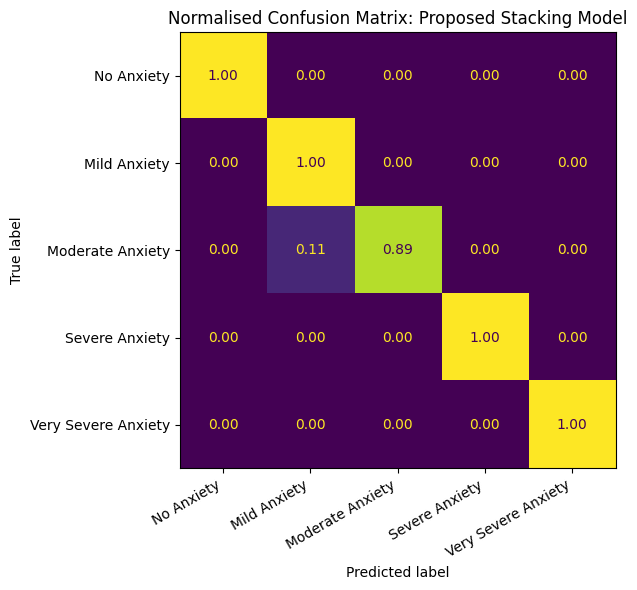

In [20]:

recall_df = per_class_recall_table(main_predictions, y_test)
print(recall_df)
recall_df.to_csv(OUTPUT_DIR / "per_class_recall_table.csv", index=False)

# Normalised confusion matrix for the proposed model.
cm = confusion_matrix(y_test, stack_pred, labels=LABELS, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format=".2f", colorbar=False)
ax.set_title("Normalised Confusion Matrix: Proposed Stacking Model")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_stacking.png", dpi=300)
plt.show()

## 20. Figures for Manuscript

The following figures are intended for manuscript use. Avoid redundant line charts because model names do not represent an ordered temporal trend.

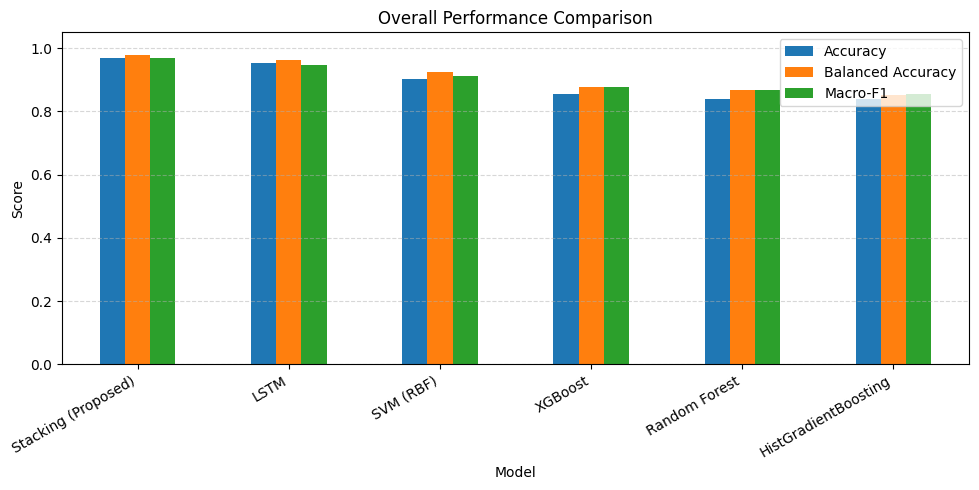

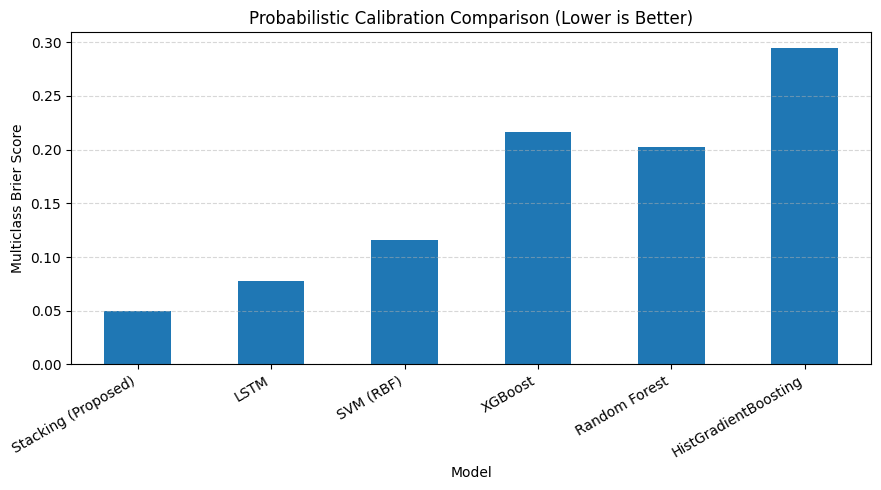

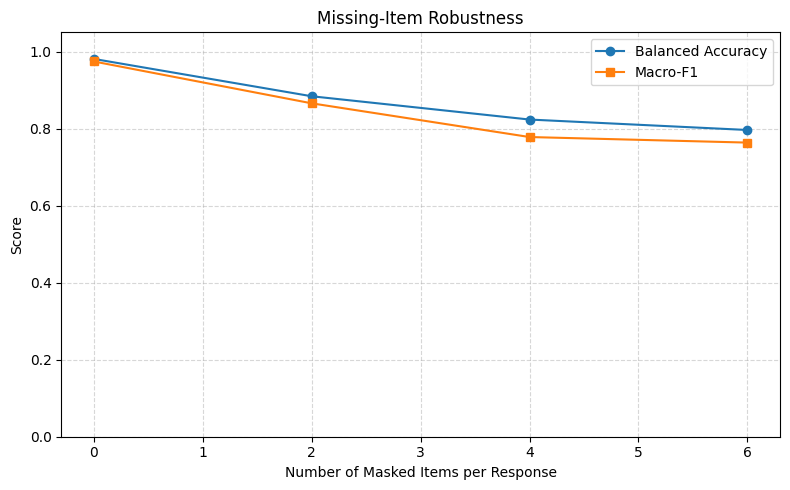

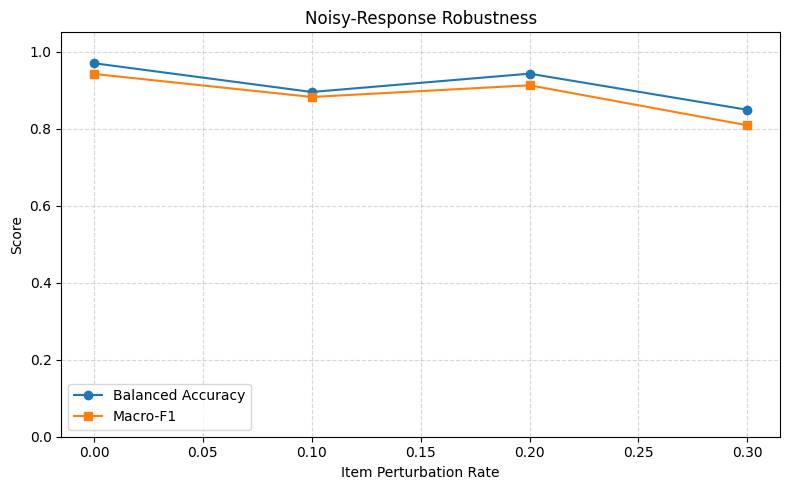

In [21]:

# Main performance comparison.
plot_df = main_results_df.set_index("Model").loc[:, ["Accuracy", "Balanced Accuracy", "Macro-F1"]]
fig, ax = plt.subplots(figsize=(10, 5))
plot_df.plot(kind="bar", ax=ax)
ax.set_ylim(0.0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Overall Performance Comparison")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "overall_performance_comparison.png", dpi=300)
plt.show()

# Brier score comparison.
brier_df = main_results_df.dropna(subset=["Brier Score"]).set_index("Model")["Brier Score"]
fig, ax = plt.subplots(figsize=(9, 5))
brier_df.plot(kind="bar", ax=ax)
ax.set_ylabel("Multiclass Brier Score")
ax.set_title("Probabilistic Calibration Comparison (Lower is Better)")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "brier_score_comparison.png", dpi=300)
plt.show()

# Robustness plots.
if len(missing_results_df) > 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(missing_results_df["Missing Items per Response"], missing_results_df["Balanced Accuracy"], marker="o", label="Balanced Accuracy")
    ax.plot(missing_results_df["Missing Items per Response"], missing_results_df["Macro-F1"], marker="s", label="Macro-F1")
    ax.set_xlabel("Number of Masked Items per Response")
    ax.set_ylabel("Score")
    ax.set_title("Missing-Item Robustness")
    ax.set_ylim(0.0, 1.05)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "missing_item_robustness.png", dpi=300)
    plt.show()

if len(noise_results_df) > 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(noise_results_df["Noise Rate"], noise_results_df["Balanced Accuracy"], marker="o", label="Balanced Accuracy")
    ax.plot(noise_results_df["Noise Rate"], noise_results_df["Macro-F1"], marker="s", label="Macro-F1")
    ax.set_xlabel("Item Perturbation Rate")
    ax.set_ylabel("Score")
    ax.set_title("Noisy-Response Robustness")
    ax.set_ylim(0.0, 1.05)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "noisy_response_robustness.png", dpi=300)
    plt.show()

## 21. Export Summary

The exported tables and figures should be used as the sole source of numerical values for the revised manuscript and rebuttal letter.

In [22]:

print("Exported files:")
for path in sorted(OUTPUT_DIR.glob("*")):
    print("-", path)

print("Recommended manuscript wording:")
print("The revised analysis excludes explicit aggregate-score inputs and frames the task as score-derived HARS severity approximation rather than independent clinical prediction.")
print("The deterministic HARS scoring rule is reported only as a label-generating reference, not as a competing predictive model.")
print("Feature ablation, missing-item robustness, and noisy-response robustness analyses are used to evaluate the role of item-response representations beyond complete clean scoring conditions.")

Exported files:
- /content/revised_hars_outputs/brier_score_comparison.png
- /content/revised_hars_outputs/class_distribution.csv
- /content/revised_hars_outputs/confusion_matrix_stacking.png
- /content/revised_hars_outputs/feature_ablation_table.csv
- /content/revised_hars_outputs/feature_representation_summary.csv
- /content/revised_hars_outputs/main_performance_table.csv
- /content/revised_hars_outputs/missing_item_robustness.png
- /content/revised_hars_outputs/missing_item_robustness_table.csv
- /content/revised_hars_outputs/noisy_response_robustness.png
- /content/revised_hars_outputs/noisy_response_robustness_table.csv
- /content/revised_hars_outputs/overall_performance_comparison.png
- /content/revised_hars_outputs/per_class_recall_table.csv
- /content/revised_hars_outputs/reliability_analysis.csv
Recommended manuscript wording:
The revised analysis excludes explicit aggregate-score inputs and frames the task as score-derived HARS severity approximation rather than independent c